In [1]:
# !gdown 1jxSR9Cov4XaTXY1kPUnMFk7MaXR-bcQ5

In [2]:
FILE_PATH = 'Transactions.csv'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle
import numpy as np
pd.set_option('display.float_format', '{:,.5f}'.format)


In [4]:
def format_num(num):
  return "{:,}".format(num)

def df_status(df):
    print(f"{format_num(len(df))} Samples & {len(df.columns)} Features")

In [5]:
df = pd.read_csv(FILE_PATH)

In [6]:
df.columns
df.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2006-163,9,3,هبات,Gifts,هبه,Grant,16-10-2006,4,فيلا,...,NaN,0,"3,162.42000","12,000,000.00000","3,794.56000",NaN,NaN,3.00000,1.00000,0.00000
1,3-9-2019-2944,9,3,هبات,Gifts,هبه,Grant,13-11-2019,1,أرض,...,NaN,0,209.09000,"916,659.00000","4,384.04000",NaN,NaN,2.00000,4.00000,0.00000
2,2-13-1999-347,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,22-03-1999,1,أرض,...,NaN,0,"1,062.72000","1,200,000.00000","1,129.18000",NaN,NaN,1.00000,1.00000,0.00000
3,2-13-2001-547,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,23-07-2001,2,مبنى,...,NaN,0,"1,393.55000","3,500,000.00000","2,511.57000",NaN,NaN,5.00000,1.00000,0.00000
4,2-13-2020-9477,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,30-11-2020,2,مبنى,...,NaN,0,278.71000,"2,500,000.00000","8,969.90000",NaN,NaN,1.00000,1.00000,0.00000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1665112 entries, 0 to 1665111
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1665112 non-null  str    
 1   procedure_id          1665112 non-null  int64  
 2   trans_group_id        1665112 non-null  int64  
 3   trans_group_ar        1665112 non-null  str    
 4   trans_group_en        1665112 non-null  str    
 5   procedure_name_ar     1665112 non-null  str    
 6   procedure_name_en     1665112 non-null  str    
 7   instance_date         1665112 non-null  str    
 8   property_type_id      1665112 non-null  int64  
 9   property_type_ar      1665112 non-null  str    
 10  property_type_en      1665112 non-null  str    
 11  property_sub_type_id  1330409 non-null  float64
 12  property_sub_type_ar  1330409 non-null  str    
 13  property_sub_type_en  1330409 non-null  str    
 14  property_usage_ar     1665112 non-null  str  

In [8]:
df['procedure_name_en'].unique()

<StringArray>
[                                           'Grant',
                            'Mortgage Registration',
                                             'Sell',
                              'Adding Land By Sell',
                                  'Modify Mortgage',
                              'Lease to Own Modify',
                                'Mortgage Transfer',
                        'Lease to Own Registration',
                         'Development Registration',
                                     'Delayed Sell',
                          'Sell - Pre registration',
                        'Mortgage Pre-Registration',
                       'Lease Finance Registration',
                  'Portfolio Mortgage Registration',
                                 'Delayed Mortgage',
       'Lease to Own Registration Pre-Registration',
                            'Lease to Own Transfer',
                'Delayed Lease to Own Registration',
                           'Gran

# Data Pre-Processing


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1665112 entries, 0 to 1665111
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1665112 non-null  str    
 1   procedure_id          1665112 non-null  int64  
 2   trans_group_id        1665112 non-null  int64  
 3   trans_group_ar        1665112 non-null  str    
 4   trans_group_en        1665112 non-null  str    
 5   procedure_name_ar     1665112 non-null  str    
 6   procedure_name_en     1665112 non-null  str    
 7   instance_date         1665112 non-null  str    
 8   property_type_id      1665112 non-null  int64  
 9   property_type_ar      1665112 non-null  str    
 10  property_type_en      1665112 non-null  str    
 11  property_sub_type_id  1330409 non-null  float64
 12  property_sub_type_ar  1330409 non-null  str    
 13  property_sub_type_en  1330409 non-null  str    
 14  property_usage_ar     1665112 non-null  str  

In [10]:
df['parsed_date'] = pd.to_datetime(df['instance_date'], format='%d-%m-%Y')

In [11]:
df['property_sub_type_en'].unique()

<StringArray>
[                 nan,             'Office',               'Flat',
               'Shop',              'Store',              'Villa',
    'Hotel Apartment',        'Hotel Rooms',              'Hotel',
             'Clinic',           'Building',          'Warehouse',
 'Stacked Townhouses',           'Workshop',    'Sized Partition',
         'Show Rooms',          'Gymnasium',               'Unit',
            'Parking']
Length: 19, dtype: str

In [12]:
print("\n\nLast 10 Entries \n\n")
print(df.sort_values(by='parsed_date').tail(10))
print("\n\n-----------------")
print("\n\nFirst 10 Entries \n\n")
print(df.sort_values(by='parsed_date').head(10))



Last 10 Entries 


           transaction_id  procedure_id  trans_group_id trans_group_ar  \
1202936    1-11-2026-7315            11               1        مبايعات   
202712   1-102-2026-17220           102               1        مبايعات   
787567     1-41-2026-3020            41               1        مبايعات   
834752     1-11-2026-7071            11               1        مبايعات   
1359767  1-102-2026-17349           102               1        مبايعات   
1127727  1-102-2026-17438           102               1        مبايعات   
523002   1-102-2026-17187           102               1        مبايعات   
299852   1-102-2026-17611           102               1        مبايعات   
840667      2-14-2026-218            14               2           رهون   
539343   1-102-2026-17140           102               1        مبايعات   

        trans_group_en  procedure_name_ar        procedure_name_en  \
1202936          Sales                بيع                     Sell   
202712           Sales  

In [13]:
# the first four transactions are from 1416 to 1422 which seems weird and can be removed. They will skew the data unnecessarily

### We have transaction data from 18th January, 1966 to 12th June, 2025

In [14]:
df[df['parsed_date'].isna()]

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date


In [15]:
df1 = df[4:].reset_index(drop=True)

In [16]:
print(f"Total transactions earlier: {len(df)}")
print(f"Total transactions now: {len(df1)}")

Total transactions earlier: 1665112
Total transactions now: 1665108


In [17]:
print(f"Earliest transaction earlier was {df.loc[0, 'parsed_date']}")
print(f"Earliest transaction now is {df1.loc[0, 'parsed_date']}")

Earliest transaction earlier was 2006-10-16 00:00:00
Earliest transaction now is 2020-11-30 00:00:00


## Now we are left with 14,75,496 transactions

In [18]:
df1.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
0,2-13-2020-9477,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,30-11-2020,2,مبنى,...,0,278.71000,"2,500,000.00000","8,969.90000",NaN,NaN,1.00000,1.00000,0.00000,2020-11-30
1,3-9-2002-70,9,3,هبات,Gifts,هبه,Grant,29-05-2002,4,فيلا,...,0,276.39000,"500,000.00000","1,809.04000",NaN,NaN,1.00000,1.00000,0.00000,2002-05-29
2,1-11-2013-15239,11,1,مبايعات,Sales,بيع,Sell,16-05-2013,4,فيلا,...,0,382.67000,"2,000,000.00000","5,226.44000",NaN,NaN,1.00000,1.00000,0.00000,2013-05-16
3,1-4-2012-13,4,1,مبايعات,Sales,إضافة أرض بالبيع,Adding Land By Sell,19-04-2012,2,مبنى,...,0,346.81000,"920,700.00000","2,654.77000",NaN,NaN,1.00000,1.00000,0.00000,2012-04-19
4,2-13-1999-532,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,26-04-1999,4,فيلا,...,0,"3,626.93000","1,900,000.00000",523.86000,NaN,NaN,1.00000,1.00000,0.00000,1999-04-26


## Dropping Non-Informative Arabic Columns


In [19]:
ar_columns = [column for column in df1.columns.to_list() if column.endswith('_ar')]
ar_columns

['trans_group_ar',
 'procedure_name_ar',
 'property_type_ar',
 'property_sub_type_ar',
 'property_usage_ar',
 'reg_type_ar',
 'area_name_ar',
 'building_name_ar',
 'project_name_ar',
 'master_project_ar',
 'nearest_landmark_ar',
 'nearest_metro_ar',
 'nearest_mall_ar',
 'rooms_ar']

In [20]:
df2 = df1.drop(columns=ar_columns)

In [21]:
df2.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'instance_date', 'property_type_id',
       'property_type_en', 'property_sub_type_id', 'property_sub_type_en',
       'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [22]:
df2.property_usage_en.unique()

<StringArray>
[                          'Residential',
                            'Commercial',
                            'Industrial',
              'Residential / Commercial',
                                 'Other',
                             'Multi-Use',
                               'Storage',
                          'Agricultural',
                          'Hospitality ',
               'Industrial / Commercial',
 'Industrial / Commercial / Residential']
Length: 11, dtype: str

## Filtering observations by Property Classifications

`property_usage_en` column

We need to make a decision to use which all properties from `property_usage_en`.
eg: If we want to just use Residential properties, then we need to filter out the usage types of following:
1. Residential
2. Residential / Commercial
3. Industrial / Commercial / Residential
4. Multi-Use

_Multi-Use might be removed seeing it's values_

In [23]:
allowed_usages = ['Residential', 'Residential / Commercial', 'Industrial / Commercial / Residential', 'Multi-Use']
res_df = df2[df2['property_usage_en'].isin(allowed_usages)]

In [24]:
res_df.info()

<class 'pandas.DataFrame'>
Index: 1406101 entries, 0 to 1665107
Data columns (total 33 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1406101 non-null  str           
 1   procedure_id          1406101 non-null  int64         
 2   trans_group_id        1406101 non-null  int64         
 3   trans_group_en        1406101 non-null  str           
 4   procedure_name_en     1406101 non-null  str           
 5   instance_date         1406101 non-null  str           
 6   property_type_id      1406101 non-null  int64         
 7   property_type_en      1406101 non-null  str           
 8   property_sub_type_id  1200852 non-null  float64       
 9   property_sub_type_en  1200852 non-null  str           
 10  property_usage_en     1406101 non-null  str           
 11  reg_type_id           1406101 non-null  int64         
 12  reg_type_en           1406101 non-null  str           
 13

## 14,75,499 samples & 33 features

Property Type Evaluation

In [25]:
res_df.property_type_en.unique()

<StringArray>
['Building', 'Villa', 'Land', 'Unit']
Length: 4, dtype: str

We have 'Villa', 'Building', 'Land', 'Unit' types of properties

In [26]:
# For this model, let's focus on "Unit" type

res_units = res_df[res_df['property_type_en'] == 'Unit']
res_units2 = res_units.drop(columns=['property_type_en', 'property_type_id'])
res_units2.info()

<class 'pandas.DataFrame'>
Index: 1055514 entries, 370 to 1665107
Data columns (total 31 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1055514 non-null  str           
 1   procedure_id          1055514 non-null  int64         
 2   trans_group_id        1055514 non-null  int64         
 3   trans_group_en        1055514 non-null  str           
 4   procedure_name_en     1055514 non-null  str           
 5   instance_date         1055514 non-null  str           
 6   property_sub_type_id  1055514 non-null  float64       
 7   property_sub_type_en  1055514 non-null  str           
 8   property_usage_en     1055514 non-null  str           
 9   reg_type_id           1055514 non-null  int64         
 10  reg_type_en           1055514 non-null  str           
 11  area_id               1055514 non-null  int64         
 12  area_name_en          1055514 non-null  str           
 

## Property Subtype

In [27]:
res_units2.property_sub_type_en.unique()

<StringArray>
['Flat', 'Stacked Townhouses', 'Unit']
Length: 3, dtype: str

We have 3 types of sub types now:

1. Flat
2. Stacked Townhouses
3. Unit

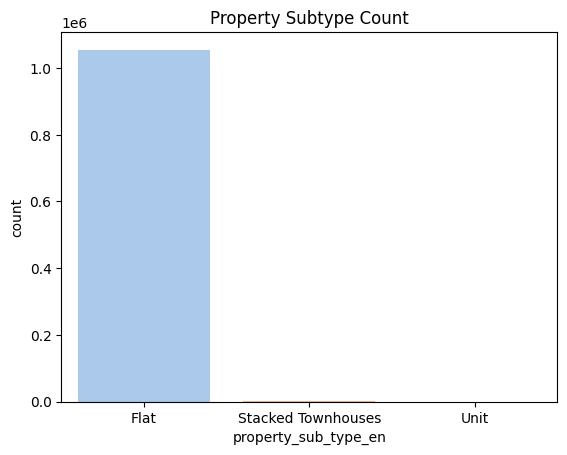

In [28]:
sns.countplot(data=res_units2, x='property_sub_type_en', legend='auto', stat='count', palette='pastel', hue='property_sub_type_en')
plt.title('Property Subtype Count')
plt.show()

In [29]:
res_units2.property_sub_type_en.value_counts()

property_sub_type_en
Flat                  1054990
Stacked Townhouses        522
Unit                        2
Name: count, dtype: int64

Since we don't want Stacked Townhouses for now and the unit is only 1 in count. It's better to just filter out the flats.

In [30]:
flats_df = res_units2[res_units2['property_sub_type_en'] == 'Flat']
flats_df2 = flats_df.drop(columns=['property_sub_type_en', 'property_sub_type_id'])
flats_df2.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 29 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   instance_date         1054990 non-null  str           
 6   property_usage_en     1054990 non-null  str           
 7   reg_type_id           1054990 non-null  int64         
 8   reg_type_en           1054990 non-null  str           
 9   area_id               1054990 non-null  int64         
 10  area_name_en          1054990 non-null  str           
 11  building_name_en      1054990 non-null  str           
 12  project_number        831676 non-null   float64       
 

## 9,11,523 Samples and 29 Features

We can remove _instance_date_, since we already have _parsed_date_

In [31]:
flats_df3 = flats_df2.drop(columns=['instance_date'])
flats_df3.shape

(1054990, 28)

## 9,11,523 Samples and 28 Features

In [32]:
flats_df3.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   property_usage_en     1054990 non-null  str           
 6   reg_type_id           1054990 non-null  int64         
 7   reg_type_en           1054990 non-null  str           
 8   area_id               1054990 non-null  int64         
 9   area_name_en          1054990 non-null  str           
 10  building_name_en      1054990 non-null  str           
 11  project_number        831676 non-null   float64       
 12  project_name_en       831676 non-null   str           
 

In [33]:
flats_df3.property_usage_en.value_counts()

property_usage_en
Residential    1054990
Name: count, dtype: int64

## Property Usage

Only 1 value type now exists, we can remove it.

In [34]:
flats_df4 = flats_df3.drop(columns=['property_usage_en'])
flats_df4.shape

(1054990, 27)

In [35]:
flats_df4.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   reg_type_id           1054990 non-null  int64         
 6   reg_type_en           1054990 non-null  str           
 7   area_id               1054990 non-null  int64         
 8   area_name_en          1054990 non-null  str           
 9   building_name_en      1054990 non-null  str           
 10  project_number        831676 non-null   float64       
 11  project_name_en       831676 non-null   str           
 12  master_project_en     997332 non-null   str           
 

## 9,11,523 Samples & 27 Features

## Registration type

## 12,61,949 samples & 33 features left

## Dropping Non-Informative Identifier Columns

In [36]:
flats_df4.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [37]:
flats_df4.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   reg_type_id           1054990 non-null  int64         
 6   reg_type_en           1054990 non-null  str           
 7   area_id               1054990 non-null  int64         
 8   area_name_en          1054990 non-null  str           
 9   building_name_en      1054990 non-null  str           
 10  project_number        831676 non-null   float64       
 11  project_name_en       831676 non-null   str           
 12  master_project_en     997332 non-null   str           
 

In [38]:
for column in flats_df4.columns.to_list():
    print(f"Unique value count for {column}: {res_df[column].nunique()}")

Unique value count for transaction_id: 1406101
Unique value count for procedure_id: 49
Unique value count for trans_group_id: 3
Unique value count for trans_group_en: 3
Unique value count for procedure_name_en: 49
Unique value count for reg_type_id: 2
Unique value count for reg_type_en: 2
Unique value count for area_id: 216
Unique value count for area_name_en: 216
Unique value count for building_name_en: 4446
Unique value count for project_number: 2912
Unique value count for project_name_en: 2908
Unique value count for master_project_en: 159
Unique value count for nearest_landmark_en: 14
Unique value count for nearest_metro_en: 55
Unique value count for nearest_mall_en: 5
Unique value count for rooms_en: 15
Unique value count for has_parking: 2
Unique value count for procedure_area: 71074
Unique value count for actual_worth: 302489
Unique value count for meter_sale_price: 799228
Unique value count for rent_value: 13090
Unique value count for meter_rent_price: 25659
Unique value count f

In [39]:
## Dropping transaction_id column
flats_df5 = flats_df4.drop(columns=['transaction_id'])

In [40]:
flats_df5.head()

,procedure_id,trans_group_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
370,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,...,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15
371,110,1,Sales,Lease to Own Registration,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,...,1,316.71000,"4,641,888.00000","14,656.59000",NaN,NaN,2.00000,2.00000,2.00000,2009-11-24
372,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 2,NaN,...,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01
379,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16
380,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07


## Evaluating `procedure_id` and `procedure_name_en`

In [41]:
flats_df5.columns

Index(['procedure_id', 'trans_group_id', 'trans_group_en', 'procedure_name_en',
       'reg_type_id', 'reg_type_en', 'area_id', 'area_name_en',
       'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [42]:
flats_df5.procedure_name_en.nunique()

38

In [43]:
flats_df5.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration                       464877
Sell                                          311336
Mortgage Registration                         103423
Delayed Sell                                   48057
Lease to Own Registration                      37532
Grant                                          27933
Delayed Mortgage                                7935
Sell Development                                7737
Development Registration                        7345
Lease to Own Registration Pre-Registration      6133
Modify Mortgage                                 4991
Lease Finance Registration                      4751
Mortgage Pre-Registration                       4435
Development Mortgage                            3702
Development Registration Pre-Registration       3260
Grant Pre-Registration                          2236
Sale On Payment Plan                            1885
Delayed Development                             1280
Mortgage Transfer           

In [44]:
len(flats_df5)

1054990

## ❗ Need more information on transaction procedure

Need to know which all types of transactions to use based on `procedure_name_en`

In [45]:
# Sell - Pre registration                       372812
# Sell                                          286038
# Mortgage Registration                          89645
# Delayed Sell                                   44974
# Lease to Own Registration                      36600
# Grant                                          24878
# Development Registration                        7094
# Sell Development                                6954
# Delayed Mortgage                                6608
# Lease to Own Registration Pre-Registration      6129
# Lease Finance Registration

# most_likely_needed_procedures = ['Sell - Pre registration', 'Sell', 'Mortgage Registration', 
#                                  'Delayed Sell', 'Lease to Own Registration', 'Grant',
#                                  'Development Registration', 'Sell Development',
#                                  'Delayed Mortgage', 'Lease to Own Registration Pre-Registration',
#                                  'Lease Finance Registration']

most_likely_needed_procedures = ['Sell - Pre registration', 'Sell']

In [46]:
likely_needed_transactions = len(flats_df5[flats_df5['procedure_name_en'].isin(most_likely_needed_procedures)])
total_transactions = len(flats_df5)

print(f"Likely needed transactions are {round(likely_needed_transactions/total_transactions * 100, 2)}% of total transactions")

Likely needed transactions are 73.58% of total transactions


In [47]:
flats_df6 = flats_df5[flats_df5['procedure_name_en'].isin(most_likely_needed_procedures)]

In [48]:
flats_df6.head()

,procedure_id,trans_group_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
370,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,...,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15
372,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 2,NaN,...,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01
379,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16
380,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07
381,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,1.00000,2.00000,0.00000,2024-02-29


## Transaction Group

This has 2 columns:
1. trans_group_id (Identifier)
2. trans_group_en (Value)

In [49]:
flats_df6.trans_group_en.unique()

<StringArray>
['Sales']
Length: 1, dtype: str

In [50]:
flats_df6.trans_group_en.value_counts()

trans_group_en
Sales    776213
Name: count, dtype: int64

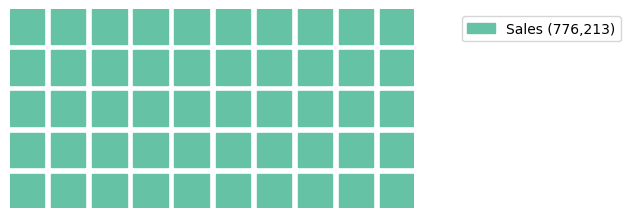

In [51]:
fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=10,
    values=flats_df6.trans_group_en.value_counts(),
    legend={
        'labels': [f"{k} ({format_num(v)})" for k, v in flats_df6.trans_group_en.value_counts().items()],
        'loc': 'upper left',
        'bbox_to_anchor': (1.1, 1)
    }
)
fig.savefig('transaction_group_composition.png')
plt.show()

In [52]:
flats_df6[flats_df6.trans_group_en == 'Gifts'][['meter_sale_price', 'procedure_area', 'actual_worth']].head()

,meter_sale_price,procedure_area,actual_worth


In [53]:
flats_df6[flats_df6.trans_group_en == 'Sales'][['meter_sale_price', 'procedure_area', 'actual_worth']].head()

,meter_sale_price,procedure_area,actual_worth
370,"11,953.35000",85.75000,"1,025,000.00000"
372,"7,436.33000",161.37000,"1,200,000.00000"
379,"22,983.56000",130.18000,"2,992,000.00000"
380,"26,641.55000",130.06000,"3,465,000.00000"
381,"27,621.73000",130.25000,"3,597,730.00000"


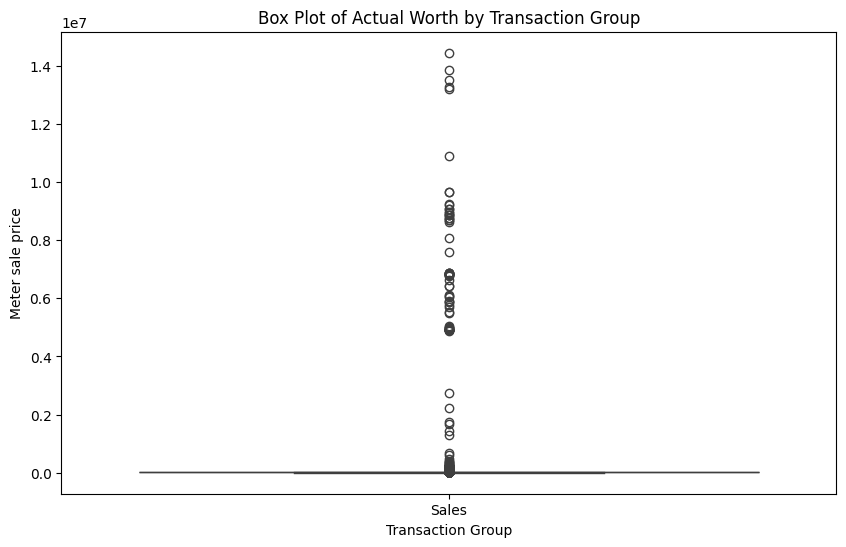

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=flats_df6, x='trans_group_en', y='meter_sale_price')
plt.title('Box Plot of Actual Worth by Transaction Group')
plt.xlabel('Transaction Group')
plt.ylabel('Meter sale price')
plt.show()

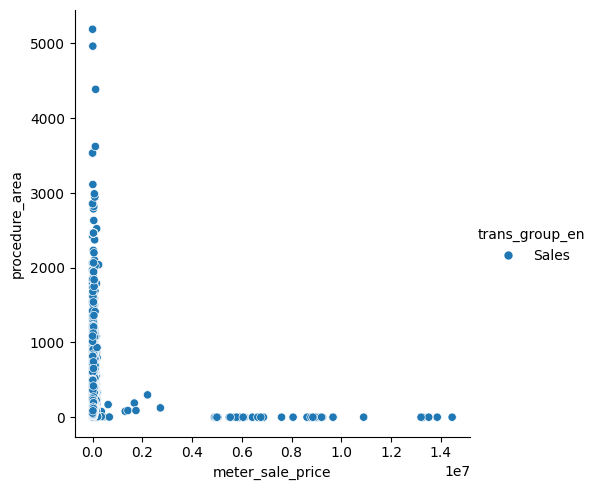

In [55]:
sns.relplot(data=flats_df6, x='meter_sale_price', y='procedure_area', hue='trans_group_en')

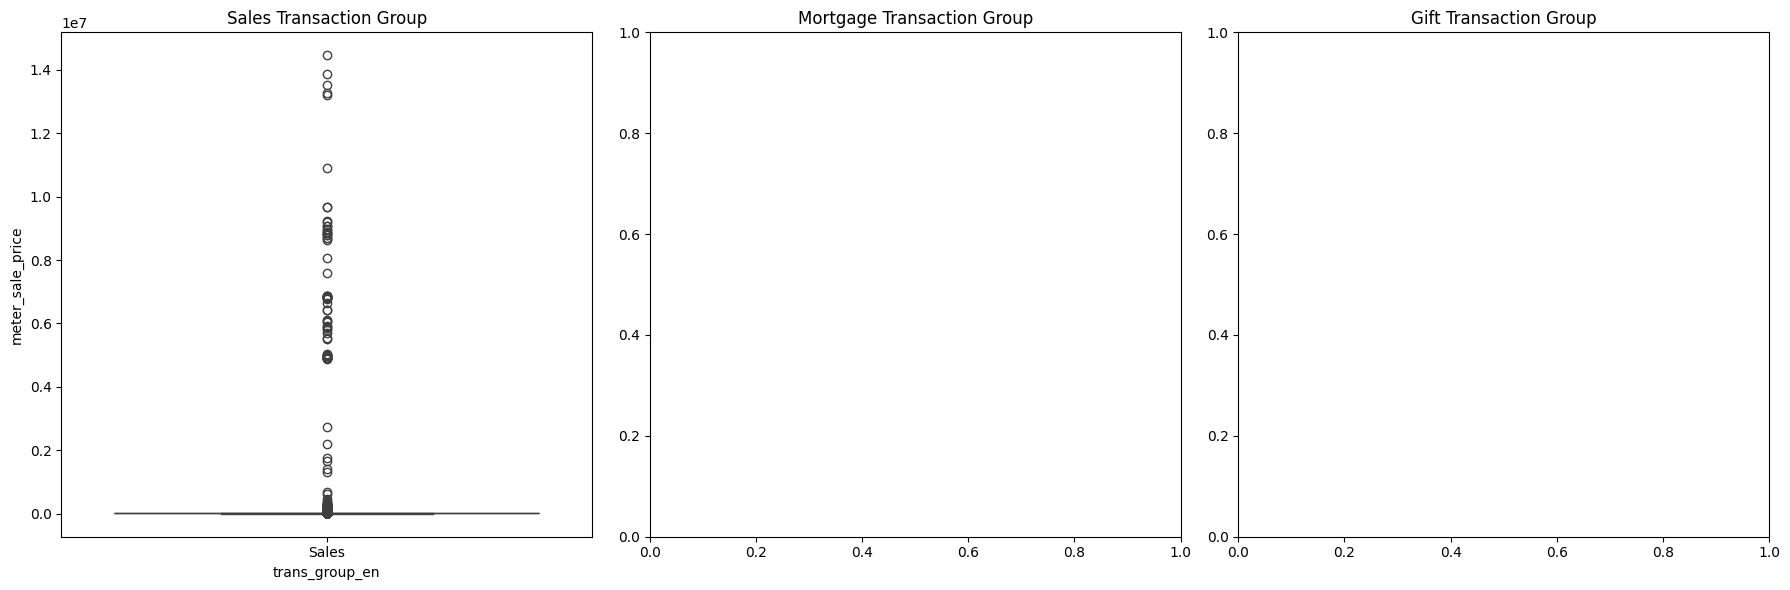

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sales_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Sales']
mortgage_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Mortgages']
gift_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Gifts']

sns.boxplot(
    data=sales_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[0]
)

sns.boxplot(
    data=mortgage_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[1]
)

sns.boxplot(
    data=gift_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[2]
)

axes[0].set_title('Sales Transaction Group')
axes[1].set_title('Mortgage Transaction Group')
axes[2].set_title('Gift Transaction Group')

plt.tight_layout()
plt.show()

In [57]:
sales_transaction_group['meter_sale_price'].describe()

count      776,213.00000
mean        17,118.40965
std         71,272.48902
min              0.01000
25%         10,042.53000
50%         14,813.73000
75%         20,804.44000
max     14,453,900.00000
Name: meter_sale_price, dtype: float64

In [58]:
mortgage_transaction_group['meter_sale_price'].describe()

count   0.00000
mean        NaN
std         NaN
min         NaN
25%         NaN
50%         NaN
75%         NaN
max         NaN
Name: meter_sale_price, dtype: float64

In [59]:
gift_transaction_group['meter_sale_price'].describe()

count   0.00000
mean        NaN
std         NaN
min         NaN
25%         NaN
50%         NaN
75%         NaN
max         NaN
Name: meter_sale_price, dtype: float64

The mean sale price for:
1. Sale properties is 16,825.9
2. Mortgage properties is 13,982
3. Gift properties is 12,714.8

In [60]:
12714/16825

0.7556612184249628

In [61]:
sale_mean_price = sales_transaction_group['meter_sale_price'].mean()
gift_mean_price = gift_transaction_group['meter_sale_price'].mean()
percent = round(gift_mean_price / sale_mean_price, 2) * 100

print(f"Gift sale price on average are {percent}% of sale mean price")

Gift sale price on average are nan% of sale mean price


In [62]:
print(f"Total sales transactions: {len(sales_transaction_group)}")
print(f"Total gift transactions: {len(gift_transaction_group)}")

print(f"Sales tr percentage: {round(len(sales_transaction_group)/len(flats_df6), 2) * 100}")
print(f"Gift tr percentage: {round(len(gift_transaction_group)/len(flats_df6), 2) * 100}")

Total sales transactions: 776213
Total gift transactions: 0
Sales tr percentage: 100.0
Gift tr percentage: 0.0


In [63]:
# Since gift transactions are only 3 percent we, can remove them

/var/folders/j5/b_yzj8c173n5bygl1tcrnw840000gn/T/ipykernel_77071/1359685233.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


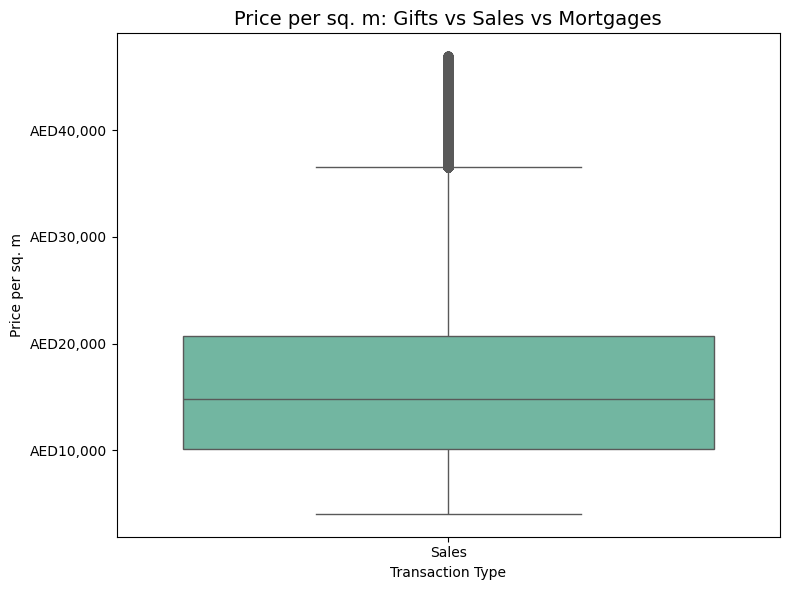

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

q_low = flats_df6['meter_sale_price'].quantile(0.01)
q_high = flats_df6['meter_sale_price'].quantile(0.99)
filtered_df = flats_df6[(flats_df6['meter_sale_price'] >= q_low) & (flats_df6['meter_sale_price'] <= q_high)]

plt.figure(figsize=(8,6))
sns.boxplot(
    x='trans_group_en',
    y='meter_sale_price',
    data=filtered_df,
    showfliers=True,
    palette="Set2"
)


import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('AED{x:,.0f}'))

plt.title("Price per sq. m: Gifts vs Sales vs Mortgages", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Price per sq. m")

plt.tight_layout()
plt.show()


In [65]:
flats_df7 = flats_df6[flats_df6['trans_group_en'] != 'Gifts']
print(f"With gift transactions, total = {len(flats_df6)}")
print(f"Without gift transactions, total = {len(flats_df7)}")

With gift transactions, total = 776213
Without gift transactions, total = 776213


In [66]:
flats_df7 = flats_df7.drop(columns=['trans_group_id', 'trans_group_en'])

In [67]:
flats_df7.shape

(776213, 24)

In [68]:
print(f"{len(flats_df7)} Samples & {len(flats_df7.columns)} Features")

776213 Samples & 24 Features


In [69]:
# flats_df7[['trans_group_en', 'procedure_name_en']].head(10)

In [70]:
flats_df7.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration    464877
Sell                       311336
Name: count, dtype: int64

In [71]:
flats_df7.head()

,procedure_id,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,project_name_en,master_project_en,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
370,11,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,NaN,NaN,...,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15
372,11,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 2,NaN,NaN,NaN,...,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01
379,102,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",VOLTA TOWER,NaN,...,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16
380,102,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",VOLTA TOWER,NaN,...,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07
381,102,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",VOLTA TOWER,NaN,...,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,1.00000,2.00000,0.00000,2024-02-29


In [72]:
flats_df7.reg_type_en.value_counts()

reg_type_en
Off-Plan Properties    464877
Existing Properties    311336
Name: count, dtype: int64

In [73]:
# from sklearn.preprocessing import OneHotEncoder

In [74]:
# encoder = OneHotEncoder(sparse_output=False)
# encoded_reg_type = encoder.fit_transform(flats_df6[['reg_type_en']])

In [75]:
# print(encoded_reg_type)

In [76]:
# encoded_reg_type

In [77]:
# encoder.get_feature_names_out(['reg_type_en'])

In [78]:
# encoded_df = pd.DataFrame(encoded_reg_type, columns=encoder.get_feature_names_out(['reg_type_en']))
# encoded_df.head()

In [79]:
# flats_df7 = pd.concat([flats_df6.drop(columns=['reg_type_en', 'reg_type_id']), encoded_df], axis=1)

In [80]:
# flats_df7.head()
# len(flats_df7)

In [81]:
# area_names_df = flats_df7.area_name_en.value_counts().reset_index()
# area_names_df.shape

## Area name en and id

In [ ]:
mapping_check = flats_df7.groupby('area_id')['area_name_en'].nunique()
type(mapping_check)

In [ ]:
print(f"No. of conflicts: {len(mapping_check[mapping_check > 1])}")

In [ ]:
flats_df8 = flats_df7.drop(columns=['area_id'])

In [ ]:
flats_df8.shape
# flats_df8.head()

In [ ]:
flats_df8.area_name_en.isna().sum()

In [ ]:
def _clean_name(name):
  if pd.isna(name):
    return 'Unknown'
  return name.strip()

In [ ]:
flats_df9 = flats_df8.drop(columns=['area_name_en'])
flats_df9['area_name_en'] = flats_df8['area_name_en'].apply(_clean_name)

In [ ]:
flats_df9['area_name_en'].value_counts()

In [ ]:
# area_name_en will use

`area_name_en` transformation will be done via OHE.

The project_number and project_name_en have a 1-1 mapping.

In [ ]:
flats_df9 = flats_df9.drop(columns=['project_number'])

In [ ]:
df_status(flats_df9)

In [ ]:
flats_df9.columns

In [ ]:
flats_df9['project_name_en'].value_counts()

In [ ]:
without_project_name = flats_df9['project_name_en'].isna().sum()

In [ ]:
print(f"There are a total of {without_project_name} Transactions without project name")
print(f"This is about {round(without_project_name/len(flats_df9),2)*100}%")
print("This can't be dropped, we need to mark them as unknown")

In [ ]:
flats_df9.drop(columns=['procedure_id'], inplace=True, errors='ignore')

In [ ]:
flats_df9.columns

## Area Name

In [ ]:
flats_df9.area_name_en.nunique()

In [ ]:
print(f"Missing area names in data: {flats_df9.area_name_en.isna().sum()}")


## Building Name

# Categorical Features


In [ ]:
flats_df9.select_dtypes(include=['str']).columns

In [ ]:
flats_df9.rooms_en.value_counts()

In [ ]:
room_map = {
    '1 B/R': 1,
    '2 B/R': 2,
    '3 B/R': 3,
    '4 B/R': 4,
    '5 B/R': 5,
    '6 B/R': 6,
    '7 B/R': 7,
    '8 B/R': 8,
    '9 B/R': 9,
    'Studio': 1,
    'Penthouse': 5,
    'Single Room': 1,
    'Shop': -1,
    'Office': -1,
}
flats_df9['rooms_num'] = flats_df9.rooms_en.map(room_map)

In [ ]:
flats_df9['rooms_num'].describe()
flats_df9.shape

In [ ]:
flats_df9.columns

In [ ]:
flats_df10 = flats_df9.drop(columns=['rooms_en'])

In [ ]:
flats_df10.columns

In [ ]:
(flats_df10.rooms_num == -1).sum()

In [ ]:
flats_df10[flats_df10.rooms_num == -1].head()

In [ ]:
# Drop samples with rooms_num = -1
flats_df11 = flats_df10[flats_df10.rooms_num != -1]


In [ ]:
df_status(flats_df10)
df_status(flats_df11)

In [ ]:
building_counts = flats_df11.building_name_en.value_counts()
building_counts

In [ ]:
print(f"No. of unique buildings: {len(building_counts)}")
print(type(building_counts))
print(building_counts.describe())
plt.hist(building_counts)
plt.xlabel('No. of Buildings')
plt.ylabel('Frequency of transactions for those buildings')

In [ ]:
mean_count = building_counts.mean()
print(f"Mean count: {round(mean_count, 2)}")

In [ ]:
flats_df11.building_name_en.isna().sum()

In [ ]:
# no_trans_group_transactions = len(flats_df11[flats_df11.trans_group_en.isna()])
# transactions_with_trans_group = len(flats_df11[~flats_df11.trans_group_en.isna()])
# print(f"Rows with trans_group_en is null : {no_trans_group_transactions}")
# print(f"Rows with trans_group_en is not null : {transactions_with_trans_group}")
# print(f"Percentage of rows with trans_group_en is null : {round((no_trans_group_transactions / len(flats_df10)) * 100, 2)}%")

In [ ]:
df_status(flats_df11)

# Non Categorical Columns

In [ ]:
non_categorical_columns = flats_df11.select_dtypes(exclude=['str']).columns

In [ ]:
non_categorical_columns

In [ ]:
flats_df11.reg_type_id.value_counts()

In [ ]:
flats_df11.reg_type_id.isna().sum()

In [ ]:
flats_df11.reg_type_en.value_counts()

In [ ]:
flats_df12 = flats_df11.drop(columns=['reg_type_en'])
## Since both reg_type_en and reg_type_id represent same thing,
## we drop reg_type_id
df_status(flats_df12)

In [ ]:
flats_df12.has_parking.value_counts()

In [ ]:
flats_df12[['procedure_area', 'meter_sale_price', 'actual_worth']]

In [ ]:
flats_df11.actual_worth.value_counts()
# actual_worth is the y
# meter_sale_price is correlated with actual_worth inversely; should be dropped
# flats_df12 = flats_df11.drop(columns=['meter_sale_price'])

In [ ]:
flats_df11.shape

### Dropping meter_rent_price
Taking assumption that won't be available in final testing, so dropping the feature

DROPPING LATER. BECAUSE OF SOME DEBUGGING

In [ ]:
# flats_df12 = flats_df11.drop(columns=['meter_rent_price', 'rent_value'])
flats_df12 = flats_df11

In [ ]:
flats_df12.head()

## Drop number of parties for registration



In [ ]:
flats_df13 = flats_df12.drop(columns=['no_of_parties_role_1','no_of_parties_role_2', 'no_of_parties_role_3'])
df_status(flats_df13)

# Final Number of Features before any encoding is 15 including target variable

In [ ]:
flats_df13.head()

# Check Target Variable

In [ ]:
flats_df13.actual_worth.describe()

In [ ]:
sns.histplot(flats_df13['actual_worth'], bins=10, kde=True)
plt.show()

In [ ]:
skewness = flats_df13['actual_worth'].skew()
print(f"Skewness: {skewness:.2f}")


In [ ]:
low_priced_transactions = flats_df13[flats_df13['actual_worth'] < 300000][['actual_worth', 'meter_sale_price', 'parsed_date']].sort_values(by='parsed_date')

In [ ]:
print(f"Total transactions lower than 300k: {len(low_priced_transactions)}")

In [ ]:
MAX_ACTUAL_WORTH = flats_df13.actual_worth.quantile(0.99)
high_priced_transactions =  flats_df13[flats_df13['actual_worth']>MAX_ACTUAL_WORTH]

In [ ]:
print(f"Total transactions greater than 99 quantile: {len(high_priced_transactions)}")

In [ ]:
# Remove low priced transactions
flats_df14 = flats_df13[flats_df13['actual_worth'] > 300000]

In [ ]:
df_status(flats_df13)
df_status(flats_df14)

In [ ]:
flats_df15 = flats_df14[flats_df14['actual_worth'] < MAX_ACTUAL_WORTH]

In [ ]:
df_status(flats_df14)
df_status(flats_df15)

In [ ]:
flats_df15['actual_worth_log'] = np.log1p(flats_df15['actual_worth'])
flats_df15.head()

In [ ]:
sns.histplot(flats_df15['actual_worth_log'], bins=30, kde=True)
plt.xlabel("Log(Price)")
plt.show()

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

In [ ]:
# flats_df14['actual_worth_scaled'] = scaler.fit_transform(
#     flats_df14[['actual_worth_log']]
# )
# flats_df14.head()

In [ ]:
# flats_df14.actual_worth_scaled.describe()

In [ ]:
# import joblib

# joblib.dump(scaler, 'actual_worth_log_scaler.pkl')

In [ ]:
# import joblib

# # Load the scaler
# scaler = joblib.load('scaler.pkl')

# # Inverse transform
# original_log_values = scaler.inverse_transform(flats_df14[['actual_worth_scaled']])
# original_values = np.expm1(original_log_values)


In [ ]:
flats_df15['actual_worth_non_log'] = np.expm1(flats_df15['actual_worth_log'])
flats_df15.head()

In [ ]:
flats_df16 = flats_df15.drop(columns=['actual_worth_non_log'])

In [ ]:
flats_df16.head()


# Feature Columns

## Handling Null Values

In [ ]:
flats_df16.columns

In [ ]:
flats_df16.isnull().mean() * 100

In [ ]:
flats_df16.columns

In [ ]:
flats_df16[flats_df16.master_project_en == 'Dubai Marina'].head(20)

In [ ]:
flats_df16.project_name_en.value_counts()

In [ ]:
flats_df16[flats_df16.building_name_en == 'Seven City JLT'].head(10)

In [ ]:
flats_df16[['building_name_en', 'project_name_en', 'master_project_en']]

In [ ]:
# Handle missing  project name

flats_df16[flats_df16.master_project_en.isna() & flats_df16.project_name_en.isna()]
flats_df17 = flats_df16.copy()
flats_df17['project_name_en'] = flats_df16['project_name_en'].fillna(flats_df16['building_name_en'])

In [ ]:
flats_df17.project_name_en.isna().sum()

In [ ]:
flats_df18 = flats_df17.copy()
flats_df18['master_project_en'] = flats_df17['master_project_en'].fillna(flats_df17['project_name_en'])

In [ ]:
flats_df18.isna().sum()

In [ ]:
flats_df18.nearest_landmark_en.value_counts()

In [ ]:
flats_df18['nearest_landmark_en'] = flats_df18.nearest_landmark_en.fillna('__MISSING__')

In [ ]:
flats_df18.isna().mean() * 100

In [ ]:
flats_df18['nearest_landmark_en'] = flats_df18.nearest_landmark_en.fillna('__MISSING__')
flats_df18['nearest_metro_en'] = flats_df18.nearest_metro_en.fillna('__MISSING__')
flats_df18['nearest_mall_en'] = flats_df18.nearest_mall_en.fillna('__MISSING__')


In [ ]:
flats_df18.isna().mean() * 100

In [ ]:
flats_df19 = flats_df18.drop(columns=['rent_value', 'meter_rent_price'])
flats_df19.isna().mean() * 100

In [ ]:
flats_df20 = flats_df19[~flats_df19['rooms_num'].isna()]
df_status(flats_df19)
df_status(flats_df20)

In [ ]:
flats_df20[flats_df20.rooms_num.isna()].head(10)

## Normalization for features

In [ ]:
numerical_columns = flats_df20.select_dtypes(exclude=['str']).columns
numerical_columns

In [ ]:
# reg_type_id and has_parking are fine.

In [ ]:
flats_df20.procedure_area.value_counts()

In [ ]:
flats_df20.procedure_area.skew()

In [ ]:
flats_df20.procedure_area.describe()

In [ ]:
flats_df20.procedure_area.quantile(0.8)
flats_df21 = flats_df20[(flats_df20.procedure_area < flats_df20.procedure_area.quantile(0.99)) &
                        (flats_df20.procedure_area > flats_df20.procedure_area.quantile(0.001))]
flats_df21.procedure_area.skew()

In [ ]:
# flats_df22 = flats_df21.drop(columns=['rooms_en'])
# len(flats_df22)

## Handle Date

In [ ]:
flats_df21.parsed_date.describe()

In [ ]:
flats_df21 = flats_df21[flats_df21.parsed_date >= '2023-06-01']
df_status(flats_df21)

In [ ]:
flats_df21.parsed_date.min()

In [ ]:
reference_date = flats_df21.parsed_date.min()
flats_df21['days_since_reference_date'] = (flats_df21.parsed_date - reference_date).dt.days
flats_df21[['parsed_date', 'days_since_reference_date']]
# flats_df22 = flats_df21.drop(columns=['parsed_date'])
# len(flats_df22)

In [ ]:
flats_df21.days_since_reference_date.skew()

In [ ]:
# flats_df21.head()
# flats_df22 = flats_df21.drop(columns='parsed_date')
flats_df22 = flats_df21
df_status(flats_df22)

In [ ]:
flats_df22['days_since_reference_date'].describe()

In [ ]:
numerical_columns = flats_df18.select_dtypes(exclude=['object']).columns
numerical_columns

In [ ]:
flats_df22.procedure_area.describe()
# flats_df18.skew()

In [ ]:
# flats_df22.procedure_area.skew()
# flats_df18['procedure_area_log'] = np.log1p(flats_df18['procedure_area'])

In [ ]:
# flats_df19 = flats_df18.drop(columns=['procedure_area'])

In [ ]:
flats_df22.days_since_reference_date.describe()

In [ ]:
flats_df22.days_since_reference_date.skew()

In [ ]:
flats_df22.isna().sum()

In [ ]:
flats_df22.info()

In [ ]:
flats_df23 = flats_df22.copy()

In [ ]:
# flats_df23 = flats_df22.drop(columns='meter_sale_price')

In [ ]:
df_status(flats_df23)

In [ ]:
categorical_columns = flats_df23.select_dtypes(include=['str']).columns
for col in categorical_columns:
    print(f"Unique counts of {col} is {flats_df23[col].nunique()}")

In [ ]:
flats_df23.building_name_en.value_counts()

In [ ]:
building_value_counts = flats_df23.building_name_en.value_counts()
type(building_value_counts)

In [ ]:
len(building_value_counts[building_value_counts < 10])

In [ ]:
rare_buildings = building_value_counts[building_value_counts < 10]
rare_buildings.index.tolist()[:10]

In [ ]:
flats_df24 = flats_df23.copy()
flats_df24.building_name_en = flats_df24.building_name_en.apply(lambda x: 'Rare' if x in rare_buildings else x)

In [ ]:
flats_df24.building_name_en.value_counts()

In [ ]:
flats_df24.head(2)

In [ ]:
flats_df25 = flats_df24.sort_values("parsed_date").reset_index(drop=True)
flats_df25.head()

In [ ]:
flats_df26 = flats_df25.drop(columns='reg_type_id')
flats_df26

In [ ]:
prices = np.expm1(flats_df26.actual_worth_log)
prices.describe()

In [ ]:
df_status(flats_df26)

In [ ]:
flats_df26.columns

In [ ]:
flats_df26['year'] = flats_df26['parsed_date'].dt.year
flats_df26['month'] = flats_df26['parsed_date'].dt.month
flats_df26['quarter'] = flats_df26['parsed_date'].dt.quarter
# flats_df26['day_of_week'] = flats_df26['parsed_date'].dt.dayofweek

In [ ]:
flats_df26.info()

In [ ]:
# cat_cols = [
#     'trans_group_en', 'procedure_name_en', 'reg_type_en', 
#     'building_name_en', 'project_name_en', 'master_project_en', 
#     'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'area_name_en'
# ]


In [ ]:
flats_df26.head()

In [ ]:
# X.head()

In [ ]:
flats_df26 = flats_df26.sort_values('parsed_date')

In [ ]:
flats_df26.info()

In [ ]:
# cat_cols = flats_df26.select_dtypes(include='str')
# for col in cat_cols:
#     flats_df26[col] = flats_df26[col].astype('category')

In [ ]:
# flats_df27 = flats_df26.drop(columns='parsed_date')
flats_df27 = flats_df26.copy()

In [ ]:
flats_df27.reg_type_en.value_counts()

In [ ]:
flats_df27.procedure_name_en.value_counts()

In [ ]:
# flats_df28 = flats_df27[(flats_df27.reg_type_en == 'Existing Properties') | (flats_df27.reg_type_en == 'Sell')]
# flats_df28 = flats_df28.drop(columns=['reg_type_en', 'procedure_name_en', 'master_project_en'])
flats_df28 = flats_df27.copy()

In [ ]:
flats_df28.head()

In [ ]:
df_status(flats_df28)

In [ ]:
building_ppm = flats_df28.groupby('building_name_en')['meter_sale_price'].median()

In [ ]:
flats_df28['building_ppm'] = flats_df28['building_name_en'].map(building_ppm)

In [ ]:
area_ppm = flats_df28.groupby('area_name_en')['meter_sale_price'].median()
flats_df28['area_ppm'] = flats_df28['area_name_en'].map(area_ppm)

In [ ]:
flats_df28["building_premium"] = flats_df28["building_ppm"] / flats_df28["area_ppm"]

In [ ]:
flats_df28['log_building_premium'] = np.log1p(flats_df28['building_premium'])

In [ ]:
flats_df28["log_area"] = np.log1p(flats_df28["procedure_area"])

In [ ]:
flats_df28 = flats_df28.sort_values("parsed_date")

In [ ]:
flats_df28.head()

In [ ]:
import pandas as pd

# 1. Create a clean, unique daily summary for the rolling calculation
daily_summary = (
    flats_df28.groupby(["building_name_en", "parsed_date"])["building_ppm"]
    .median()
    .reset_index()
    .sort_values(["building_name_en", "parsed_date"])
)

# 2. Calculate the rolling 180D median on the UNIQUE building-date pairs
# We use shift(1) to ensure we are looking at the PAST 180 days (excluding today)
rolling_results = (
    daily_summary.groupby("building_name_en")
    .rolling("180D", on="parsed_date")["building_ppm"]
    .median()
    .groupby(level=0)
    .shift(1)
    .reset_index()
)

# 3. Create a unique string key to map values back without using the index
daily_summary["map_key"] = daily_summary["building_name_en"].astype(str) + daily_summary["parsed_date"].astype(str)
mapping_dict = dict(zip(daily_summary["map_key"], rolling_results["building_ppm"]))

# 4. Map the results back to original DataFrame
flats_df28["map_key"] = flats_df28["building_name_en"].astype(str) + df["parsed_date"].astype(str)
flats_df28["building_ppm_6m"] = flats_df28["map_key"].map(mapping_dict)

flats_df28["building_ppm_6m"] = flats_df28["building_ppm_6m"].fillna(flats_df28["building_ppm"])
# # 5. Clean up the helper column
flats_df28.drop(columns=["map_key"], inplace=True)

In [ ]:
import pandas as pd

# 1. Create a clean, unique daily summary for the rolling calculation
daily_summary = (
    flats_df28.groupby(["area_name_en", "parsed_date"])["area_ppm"]
    .median()
    .reset_index()
    .sort_values(["area_name_en", "parsed_date"])
)

# 2. Calculate the rolling 90D median on the UNIQUE building-date pairs
# We use shift(1) to ensure we are looking at the PAST 90 days (excluding today)
rolling_results = (
    daily_summary.groupby("area_name_en")
    .rolling("90D", on="parsed_date")["area_ppm"]
    .median()
    .groupby(level=0)
    .shift(1)
    .reset_index()
)

# 3. Create a unique string key to map values back without using the index
daily_summary["map_key"] = daily_summary["area_name_en"].astype(str) + daily_summary["parsed_date"].astype(str)
mapping_dict = dict(zip(daily_summary["map_key"], rolling_results["area_ppm"]))

# 4. Map the results back to original DataFrame
flats_df28["map_key"] = flats_df28["area_name_en"].astype(str) + df["parsed_date"].astype(str)
flats_df28["area_ppm_3m"] = flats_df28["map_key"].map(mapping_dict)

flats_df28["area_ppm_3m"] = flats_df28["area_ppm_3m"].fillna(flats_df28["area_ppm"])
# # 5. Clean up the helper column
flats_df28.drop(columns=["map_key"], inplace=True)

In [ ]:
flats_df28["building_discount"] = flats_df28["building_ppm_6m"] - flats_df28["area_ppm"]

In [ ]:
flats_df28["building_price_est"] = flats_df28["building_ppm"] * flats_df28["procedure_area"]
flats_df28["log_building_price_est"] = np.log1p(flats_df28["building_price_est"])

In [ ]:
flats_df28["area_price_est"] = flats_df28["area_ppm"] * flats_df28["procedure_area"]
flats_df28["log_area_price_est"] = np.log1p(flats_df28["area_price_est"])

In [ ]:
flats_df28.head()

In [ ]:
# building_txn_count = flats_df28.groupby('building_name_en').size()
# flats_df29['

In [ ]:
flats_df28.columns

In [ ]:
flats_df29 = flats_df28.drop(columns=['project_name_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'parsed_date'])
df_status(flats_df29)

In [ ]:
flats_df29['actual_worth_log'].mean()

In [ ]:
target_col = 'actual_worth_log'
feature_cols = [
    "building_name_en", 
    "area_name_en",
    "rooms_num", 
    "log_area", 

    'building_ppm',
    'area_ppm_3m',
    'area_ppm',

    # 'building_premium',
    'log_building_premium',
    # "building_ppm_6m",
    # 'building_discount',

    'log_building_price_est',
    'log_area_price_est',
    
    
    "days_since_reference_date",
    "year",
    "month",
    "quarter"
]

final_df = flats_df29[feature_cols + [target_col]]

In [ ]:
cat_cols = final_df.select_dtypes(include='str')
for col in cat_cols:
    final_df[col] = final_df[col].astype('category')

In [ ]:
# Sort by date to ensure the split is chronological


X = final_df.drop(columns=['actual_worth_log'])
y = final_df['actual_worth_log']

# Use the last 10% of data as the test set
split_idx = int(len(flats_df29) * 0.85)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [ ]:
y

In [ ]:
X_train.head()

In [ ]:
X_train.info()

In [ ]:
import xgboost as xgb

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.80,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
    objective='reg:squarederror',
    enable_categorical=True
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

In [ ]:
from sklearn.metrics import mean_absolute_error
# Predict
preds_log = model.predict(X_test)

# Convert back from Log to actual Price
preds_actual = np.expm1(preds_log)
y_test_actual = np.expm1(y_test)

# Calculate Mean Absolute Error (Average error in price)
mae = mean_absolute_error(y_test_actual, preds_actual)
print(f"Average Prediction Error: {mae:.2f}")

# Feature Importance: See what actually drives the price
xgb.plot_importance(model, max_num_features=10)

In [ ]:
from sklearn.metrics import median_absolute_error
med_ae = median_absolute_error(y_test_actual, preds_actual)
print(f"Median Error: {med_ae}")

In [ ]:
prices = np.expm1(y)
prices

In [ ]:
median_price = prices.median()
print("Median price:", median_price)

In [ ]:
relative_error = (med_ae / median_price) * 100
print(f"Relative error: {relative_error:.2f}%")

In [ ]:
X_train.columns

In [ ]:
check_df = flats_df22[(flats_df22['building_name_en'] == 'Socio Tower 2') & (flats_df22['rooms_num'] == 1)]
check_df['price'] = np.expm1(check_df['actual_worth_log'])
check_df.sort_values(by='days_since_reference_date', ascending=False)[:10]

In [ ]:
from datetime import datetime, date

def get_date_features(date_str=None):
    """
    Returns:
    - days difference from 2023-06-02
    - year
    - month
    - quarter
    """
    base_date = date(2023, 6, 2)

    # Use today's date if no date string provided
    if not date_str:
        input_date = date.today()
    else:
        input_date = datetime.strptime(date_str, "%d-%m-%Y").date()

    days_diff = (input_date - base_date).days
    year = input_date.year
    month = input_date.month
    quarter = (month - 1) // 3 + 1

    return days_diff, year, month, quarter


# Examples
print(get_date_features("15-10-2020"))
print(get_date_features())        # uses today's date
print(get_date_features(None))    # also uses today's date

In [ ]:
X_train.columns

In [ ]:
building_area_map = {b: a for b, a in zip(df['building_name_en'], df['area_name_en'])}

In [ ]:
building_ppm_map = (
    flats_df28.groupby("building_name_en")["building_ppm"]
    .median()
    .to_dict()
)

area_ppm_map = (
    flats_df28.groupby("area_name_en")["area_ppm"]
    .median()
    .to_dict()
)

In [ ]:
building_ppm_6m_map = flats_df29.groupby("building_name_en")["building_ppm_6m"].median()
area_ppm_map = flats_df29.groupby("area_name_en")["area_ppm"].median()
area_ppm_3m_map = flats_df29.groupby("area_name_en")["area_ppm_3m"].median()

In [ ]:
def comparable_transactions(building_name_en,
                  procedure_area, rooms_num,
                days_since_reference_date):
    same_building_txns = final_df[final_df['building_name_en'] == building_name_en]
    similar_rooms_txns = same_building_txns[same_building_txns['rooms_num'].between(rooms_num - 1, rooms_num + 1)]
    similar_rooms_txns['procedure_area'] = np.expm1(similar_rooms_txns['log_area'])
    similar_size_txns = similar_rooms_txns[(similar_rooms_txns['procedure_area'] >= 0.7 * procedure_area) & (similar_rooms_txns['procedure_area'] <= 1.2 * procedure_area)]
    recent_txns = similar_size_txns[similar_size_txns['days_since_reference_date'].between(days_since_reference_date - 200, days_since_reference_date + 50)]
    recent_txns['price'] = np.expm1(recent_txns['actual_worth_log'])
    return recent_txns.sort_values('days_since_reference_date', ascending=False)[:5]

In [ ]:
import pickle
import numpy as np
import pandas as pd

def predict_price(building_name_en,
                  procedure_area, rooms_num):

    if building_name_en not in building_area_map:
        return 0
    
    
    area_name_en = building_area_map[building_name_en]

    building_ppm = building_ppm_map.get(building_name_en, np.nan)
    if pd.isna(building_ppm):
        building_ppm = area_ppm
    area_ppm = area_ppm_map.get(area_name_en, np.nan)
    
    building_premium = (
        building_ppm / area_ppm
        if pd.notna(building_ppm) and pd.notna(area_ppm) and area_ppm > 0
        else np.nan
    )

    building_price_est = (
    building_ppm * procedure_area if pd.notna(building_ppm) else np.nan
    )
    
    area_price_est = (
        area_ppm * procedure_area if pd.notna(area_ppm) else np.nan
    )
    
    log_building_price_est = np.log1p(building_price_est) if pd.notna(building_price_est) else np.nan
    log_area_price_est = np.log1p(area_price_est) if pd.notna(area_price_est) else np.nan

    building_ppm_6m = building_ppm_6m_map.get(building_name_en, np.nan)

    building_discount = building_ppm_6m - area_ppm
        
    active_model = globals().get('model')
    if active_model is None:
        with open('dubai_flats_prices.pickle', 'rb') as f:
            active_model = pickle.load(f)

    days_since_reference_date, year, month, quarter = get_date_features()
    log_area = np.log1p(procedure_area)

    row = {
        'building_name_en': building_name_en,
        'area_name_en': area_name_en,
        # 'procedure_area': float(procedure_area),
        'rooms_num': float(rooms_num),
        'log_area': log_area,

        # "building_ppm_6m": building_ppm_6m,
    
        'building_ppm': building_ppm,
        "area_ppm": area_ppm,
        "area_ppm_3m": area_ppm_3m_map.get(area_name_en, np.nan),
        
        # "building_premium": building_premium,
        # "building_ppm_6m": building_ppm_6m,
        'log_building_premium': np.log1p(building_premium),

        "log_building_price_est": log_building_price_est,
        "log_area_price_est": log_area_price_est,
    
        'days_since_reference_date': days_since_reference_date,
        'year': int(year),
        'month': int(month),
        'quarter': int(quarter),
    }

    x = pd.DataFrame([row])
    print(x.T)
    

    if hasattr(active_model, 'feature_names_in_'):
        feature_order = list(active_model.feature_names_in_)
    elif 'X_train' in globals():
        feature_order = list(X_train.columns)
    else:
        feature_order = list(x.columns)

    for col in feature_order:
        if col not in x.columns:
            x[col] = np.nan
    x = x[feature_order]

    
    categorical_cols = x.select_dtypes(include='str')
    for col in categorical_cols:
        if col in x.columns:
            x[col] = x[col].astype('category')

    log_price = float(active_model.predict(x)[0])
    price = np.expm1(log_price)

    related_transactions = X[X.building_name_en == building_name_en]
    return price, comparable_transactions(building_name_en,
                  procedure_area, rooms_num,
                days_since_reference_date)

In [ ]:
import pickle

with open('dubai_flats_prices.pickle', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
price, related_transactions = predict_price('Socio Tower 2', 45, 1)
print(price)
# print(related_transactions[['building_name_en', 'log_area', 'price']])

In [ ]:
price, related_transactions = predict_price('Seven City JLT', 35, 1)
print(price)
print(related_transactions[['building_name_en', 'procedure_area', 'price',]])

In [ ]:
flats_df28.columns

In [ ]:
recent = flats_df28[
    (flats_df28["building_name_en"] == "Seven City JLT") &
    (flats_df28["year"] >= 2024)
]

recent["meter_sale_price"].median()

In [ ]:
import matplotlib.pyplot as plt

b = flats_df28[(flats_df28["building_name_en"] == "Seven City JLT") & (flats_df28["rooms_num"] == 1)]

plt.scatter(b["procedure_area"], b["actual_worth"], alpha=0.4)
plt.xlabel("Area (sqm)")
plt.ylabel("Price")
plt.title("Seven City JLT: Price vs Area")
plt.show()

In [ ]:
b[(b["rooms_num"] == 1) & (b["procedure_area"].between(32,38))]["actual_worth"].median()

In [ ]:
# import pickle

# with open('dubai_flats_prices.pickle', 'wb') as f:
#     pickle.dump(model, f)

In [ ]:
flats_df28.columns

In [ ]:
flats_df28[flats_df28["area_name_en"]=="Al Thanyah Fifth"]["meter_sale_price"].median()

In [ ]:
model.get_booster().feature_names